# Tech Challenge FIAP - Fase 3

Autor: Sidney Filho

Objetivo:
Analisar a evolução do mercado brasileiro de Dados utilizando as pesquisas State of Data Brasil 2023, 2024 e 2025.

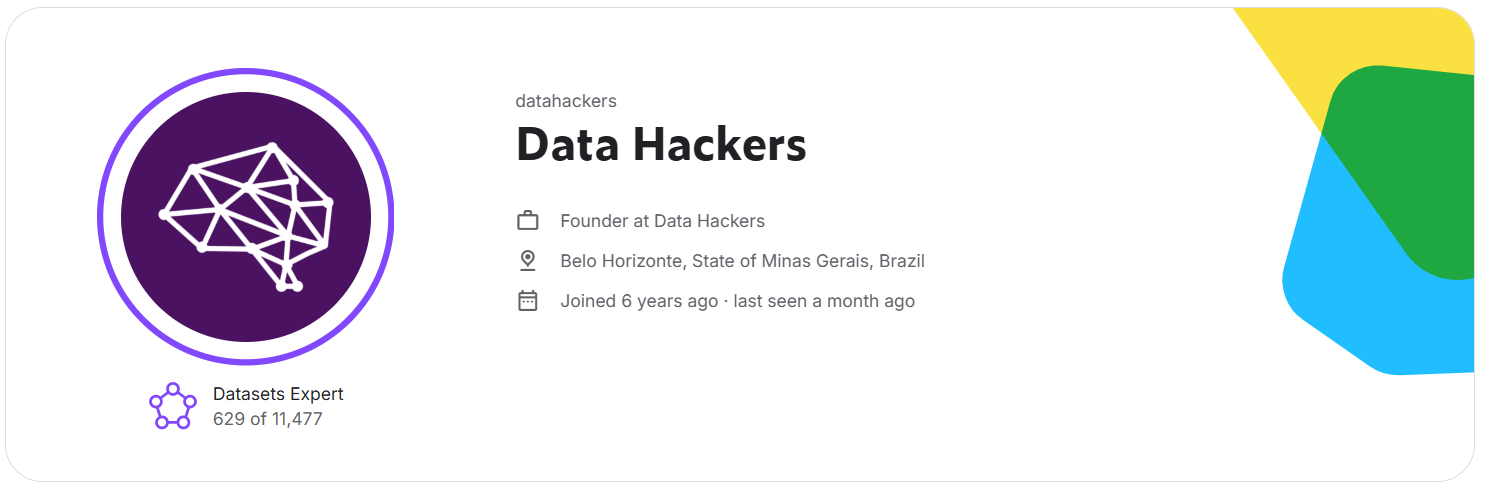

## Bibliotecas

In [132]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

## Inicialização Spark

In [133]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("StateOfDataBrasil") \
    .getOrCreate()

## Bronze

###*Leitura dos arquivos*

In [134]:
df2023 = spark.read.csv(
    "/content/State_of_data_BR_2023_Kaggle - df_survey_2023.csv",
    header=True,
    inferSchema=True
)

df2024 = spark.read.csv(
    "/content/Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv",
    header=True,
    inferSchema=True
)

df2025 = spark.read.csv(
    "/content/Final Dataset - State of Data 2025-2026 - Kaggle.csv",
    header=True,
    inferSchema=True
)

###*Adicionar metadados*

In [135]:
from pyspark.sql import functions as F

df2023 = df2023.withColumn("ano_pesquisa", F.lit(2023))
df2024 = df2024.withColumn("ano_pesquisa", F.lit(2024))
df2025 = df2025.withColumn("ano_pesquisa", F.lit(2025))

In [136]:
df2023.select("ano_pesquisa").show(3)
df2024.select("ano_pesquisa").show(3)
df2025.select("ano_pesquisa").show(3)

+------------+
|ano_pesquisa|
+------------+
|        2023|
|        2023|
|        2023|
+------------+
only showing top 3 rows
+------------+
|ano_pesquisa|
+------------+
|        2024|
|        2024|
|        2024|
+------------+
only showing top 3 rows
+------------+
|ano_pesquisa|
+------------+
|        2025|
|        2025|
|        2025|
+------------+
only showing top 3 rows


###*Resolver incompatibilidades técnicas*

In [137]:
def converter_colunas_para_string(df):
    return df.select([
        F.col(f"`{coluna.replace('`', '``')}`")
         .cast("string")
         .alias(coluna)
        for coluna in df.columns
    ])

df2023_str = converter_colunas_para_string(df2023)
df2024_str = converter_colunas_para_string(df2024)
df2025_str = converter_colunas_para_string(df2025)

###*Consolidar*

In [138]:
df_teste = df2023_str.unionByName(
    df2024_str,
    allowMissingColumns=True
)

df_total = df_teste.unionByName(
    df2025_str,
    allowMissingColumns=True
)

In [139]:
df_total.groupBy("ano_pesquisa") \
    .count() \
    .orderBy("ano_pesquisa") \
    .show()

+------------+-----+
|ano_pesquisa|count|
+------------+-----+
|        2023| 5293|
|        2024| 5217|
|        2025| 3495|
+------------+-----+



###*Validação*

In [140]:
print("Linhas esperadas: 14005")
print("Linhas encontradas:", df_total.count())
print("Colunas consolidadas:", len(df_total.columns))

Linhas esperadas: 14005
Linhas encontradas: 14005
Colunas consolidadas: 910


### Resultado da Bronze

A camada Bronze consolida as pesquisas State of Data Brasil de 2023, 2024 e 2025 em uma única estrutura de dados.

Transformações realizadas:

- Inclusão do campo `ano_pesquisa`
- Conversão de todos os campos para o tipo `string`
- Consolidação dos datasets utilizando `unionByName()`
- Preservação dos dados originais sem regras de negócio

Objetivo:

Disponibilizar uma camada bruta consolidada, servindo como base para a construção da camada Silver.

###*Persistência Bronze*

In [141]:
df_total.write.mode("overwrite").parquet(
    "/content/bronze_state_of_data"
)

print("Bronze salva com sucesso")

Bronze salva com sucesso


*Log*

In [142]:
print("Bronze criada")

print(
    "Registros:",
    df_total.count()
)

print(
    "Colunas:",
    len(df_total.columns)
)

Bronze criada
Registros: 14005
Colunas: 910


## Silver

###*Mapeamento dos Campos*

As pesquisas possuem nomenclaturas diferentes entre os anos.

Exemplos:

2023:
('P1_a ', 'Idade')

2024/2025:
1.a_idade

A camada Silver unifica esses campos utilizando coalesce().

###*Consolidar os campos*

In [143]:
silver = df_total.select(

    F.col("ano_pesquisa"),

    F.coalesce(
        F.col("`('P1_a ', 'Idade')`"),
        F.col("`1.a_idade`")
    ).alias("idade"),

    F.coalesce(
        F.col("`('P1_b ', 'Genero')`"),
        F.col("`1.b_genero`")
    ).alias("genero"),

    F.coalesce(
        F.col("`('P1_i_2 ', 'Regiao onde mora')`"),
        F.col("`1.i.2_regiao_onde_mora`")
    ).alias("regiao"),

    F.coalesce(
        F.col("`('P2_f ', 'Cargo Atual')`"),
        F.col("`2.f_cargo_atual`")
    ).alias("cargo"),

    F.coalesce(
        F.col("`('P2_r ', 'Atualmente qual a sua forma de trabalho?')`"),
        F.col("`2.q_modelo_de_trabalho_atual`"),
        F.col("`2.r_modelo_de_trabalho_atual`")
    ).alias("modelo_trabalho"),

    F.coalesce(
        F.col("`4.m_usa_chatgpt_ou_copilot_no_trabalho?`"),
        F.col("`4.j_usa_chatgpt_ou_copilot_no_trabalho?`")
    ).alias("uso_ia")

)

In [144]:
silver.show(20, truncate=False)


+------------+-----+---------+------------+-------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------+------+
|ano_pesquisa|idade|genero   |regiao      |cargo                                                              |modelo_trabalho                                                                                               |uso_ia|
+------------+-----+---------+------------+-------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------+------+
|2023        |31   |Masculino|Sudeste     |Cientista de Dados/Data Scientist                                  |Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)|NULL  |
|2023        |30   |Masculino|Sudeste     |Analista de BI/BI Analyst            

###*Validação*

In [145]:
print("Linhas:", silver.count())
print("Colunas:", len(silver.columns))

Linhas: 14005
Colunas: 7


In [146]:
silver = silver.withColumn(
    "idade",
    F.col("idade").cast("integer")
)

In [147]:
silver.printSchema()

root
 |-- ano_pesquisa: string (nullable = false)
 |-- idade: integer (nullable = true)
 |-- genero: string (nullable = true)
 |-- regiao: string (nullable = true)
 |-- cargo: string (nullable = true)
 |-- modelo_trabalho: string (nullable = true)
 |-- uso_ia: string (nullable = true)



In [148]:
silver.select([
    F.count(c).alias(c)
    for c in silver.columns
]).show(truncate=False)

+------------+-----+------+------+-----+---------------+------+
|ano_pesquisa|idade|genero|regiao|cargo|modelo_trabalho|uso_ia|
+------------+-----+------+------+-----+---------------+------+
|14005       |14005|14005 |13614 |10176|12844          |5725  |
+------------+-----+------+------+-----+---------------+------+



###*Persistência Silver*

###*Resultado da Silver*

A camada Silver consolida os principais atributos de negócio presentes nas pesquisas State of Data Brasil.

Campos consolidados:

- ano_pesquisa
- idade
- genero
- regiao
- cargo
- modelo_trabalho
- uso_ia

Transformações realizadas:

- Unificação dos campos equivalentes entre 2023, 2024 e 2025 utilizando `coalesce()`
- Padronização da estrutura de dados
- Conversão da idade para formato numérico
- Preparação dos dados para construção das camadas analíticas (Gold)

Objetivo:

Disponibilizar uma camada padronizada e consistente para geração de indicadores estratégicos.

In [149]:
silver.write.mode("overwrite").parquet(
    "/content/silver_state_of_data"
)

print("Silver salva com sucesso")

Silver salva com sucesso


## Gold

A camada Gold contém os indicadores analíticos utilizados para responder às perguntas de negócio propostas pelo Tech Challenge.

Objetivo:

Transformar os dados padronizados da Silver em indicadores estratégicos para análise do mercado brasileiro de Dados.

Principais temas analisados:

- Estrutura do Mercado
- Diversidade de Gênero
- Distribuição Regional
- Modelo de Trabalho
- Adoção de IA
- IA por Cargo
- Evolução dos Cargos

###Overview

In [150]:
gold_cargos = (
    silver
    .where(F.col("cargo").isNotNull())
    .groupBy("cargo")
    .count()
    .orderBy(F.desc("count"))
)

gold_cargos.show(
    20,
    truncate=False
)

+-------------------------------------------------------------------+-----+
|cargo                                                              |count|
+-------------------------------------------------------------------+-----+
|Analista de Dados/Data Analyst                                     |2463 |
|Cientista de Dados/Data Scientist                                  |1798 |
|Analista de BI/BI Analyst                                          |1117 |
|Engenheiro de Dados/Data Engineer/Data Architect                   |1015 |
|Outra Opção                                                        |721  |
|Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect|684  |
|Analista de Negócios/Business Analyst                              |520  |
|Analytics Engineer                                                 |502  |
|Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas        |333  |
|Engenheiro de Machine Learning/ML Engineer/AI Engineer             |284  |
|Analista de

In [151]:
gold_cargos_pd = gold_cargos.toPandas()
gold_cargos_pd.head(10)

,cargo,count
0,Analista de Dados/Data Analyst,2463
1,Cientista de Dados/Data Scientist,1798
2,Analista de BI/BI Analyst,1117
3,Engenheiro de Dados/Data Engineer/Data Architect,1015
4,Outra Opção,721
5,Engenheiro de Dados/Arquiteto de Dados/Data En...,684
6,Analista de Negócios/Business Analyst,520
7,Analytics Engineer,502
8,Desenvolvedor/ Engenheiro de Software/ Analist...,333
9,Engenheiro de Machine Learning/ML Engineer/AI ...,284


###**Estrutura do Mercado Brasileiro de Dados**

In [152]:
gold_cargos = (
    silver
    .where(F.col("cargo").isNotNull())
    .groupBy("cargo")
    .count()
    .orderBy(F.desc("count"))
)

gold_cargos.show(
    20,
    truncate=False
)

+-------------------------------------------------------------------+-----+
|cargo                                                              |count|
+-------------------------------------------------------------------+-----+
|Analista de Dados/Data Analyst                                     |2463 |
|Cientista de Dados/Data Scientist                                  |1798 |
|Analista de BI/BI Analyst                                          |1117 |
|Engenheiro de Dados/Data Engineer/Data Architect                   |1015 |
|Outra Opção                                                        |721  |
|Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect|684  |
|Analista de Negócios/Business Analyst                              |520  |
|Analytics Engineer                                                 |502  |
|Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas        |333  |
|Engenheiro de Machine Learning/ML Engineer/AI Engineer             |284  |
|Analista de

In [153]:
gold_cargos_pd = gold_cargos.toPandas()
gold_cargos_pd.head(10)

,cargo,count
0,Analista de Dados/Data Analyst,2463
1,Cientista de Dados/Data Scientist,1798
2,Analista de BI/BI Analyst,1117
3,Engenheiro de Dados/Data Engineer/Data Architect,1015
4,Outra Opção,721
5,Engenheiro de Dados/Arquiteto de Dados/Data En...,684
6,Analista de Negócios/Business Analyst,520
7,Analytics Engineer,502
8,Desenvolvedor/ Engenheiro de Software/ Analist...,333
9,Engenheiro de Machine Learning/ML Engineer/AI ...,284


In [154]:
gold_cargos_pd_limpo = gold_cargos_pd.copy()

gold_cargos_pd_limpo["cargo_limpo"] = (
    gold_cargos_pd_limpo["cargo"]

    .replace({

        "Analista de Dados/Data Analyst":
        "Analista de Dados",

        "Cientista de Dados/Data Scientist":
        "Cientista de Dados",

        "Analista de BI/BI Analyst":
        "Analista de BI",

        "Analista de Negócios/Business Analyst":
        "Business Analyst",

        "Analytics Engineer":
        "Analytics Engineer",

        "Engenheiro de Machine Learning/ML Engineer/AI Engineer":
        "ML Engineer",

        "Engenheiro de Dados/Data Engineer/Data Architect":
        "Engenheiro de Dados",

        "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect":
        "Engenheiro de Dados"
    })
)

In [155]:
gold_cargos_pd_limpo = gold_cargos_pd_limpo[
    gold_cargos_pd_limpo["cargo_limpo"] != "Outra Opção"
]

gold_cargos_exec = (
    gold_cargos_pd_limpo
    .groupby("cargo_limpo")["count"]
    .sum()
    .reset_index()
    .sort_values(
        by="count",
        ascending=False
    )
)

gold_cargos_exec

,cargo_limpo,count
2,Analista de Dados,2463
8,Cientista de Dados,1798
13,Engenheiro de Dados,1699
1,Analista de BI,1117
7,Business Analyst,520
5,Analytics Engineer,502
11,Desenvolvedor/ Engenheiro de Software/ Analist...,333
15,ML Engineer,284
4,Analista de Suporte/Analista Técnico,206
10,Data Product Manager/ Product Manager (PM/APM/...,194


*Tratamento das Categorias*

Alguns cargos apresentavam nomenclaturas equivalentes entre diferentes anos da pesquisa.

Exemplo:

- Engenheiro de Dados/Data Engineer/Data Architect
- Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect

Essas categorias foram consolidadas para evitar duplicidade e melhorar a análise comparativa.

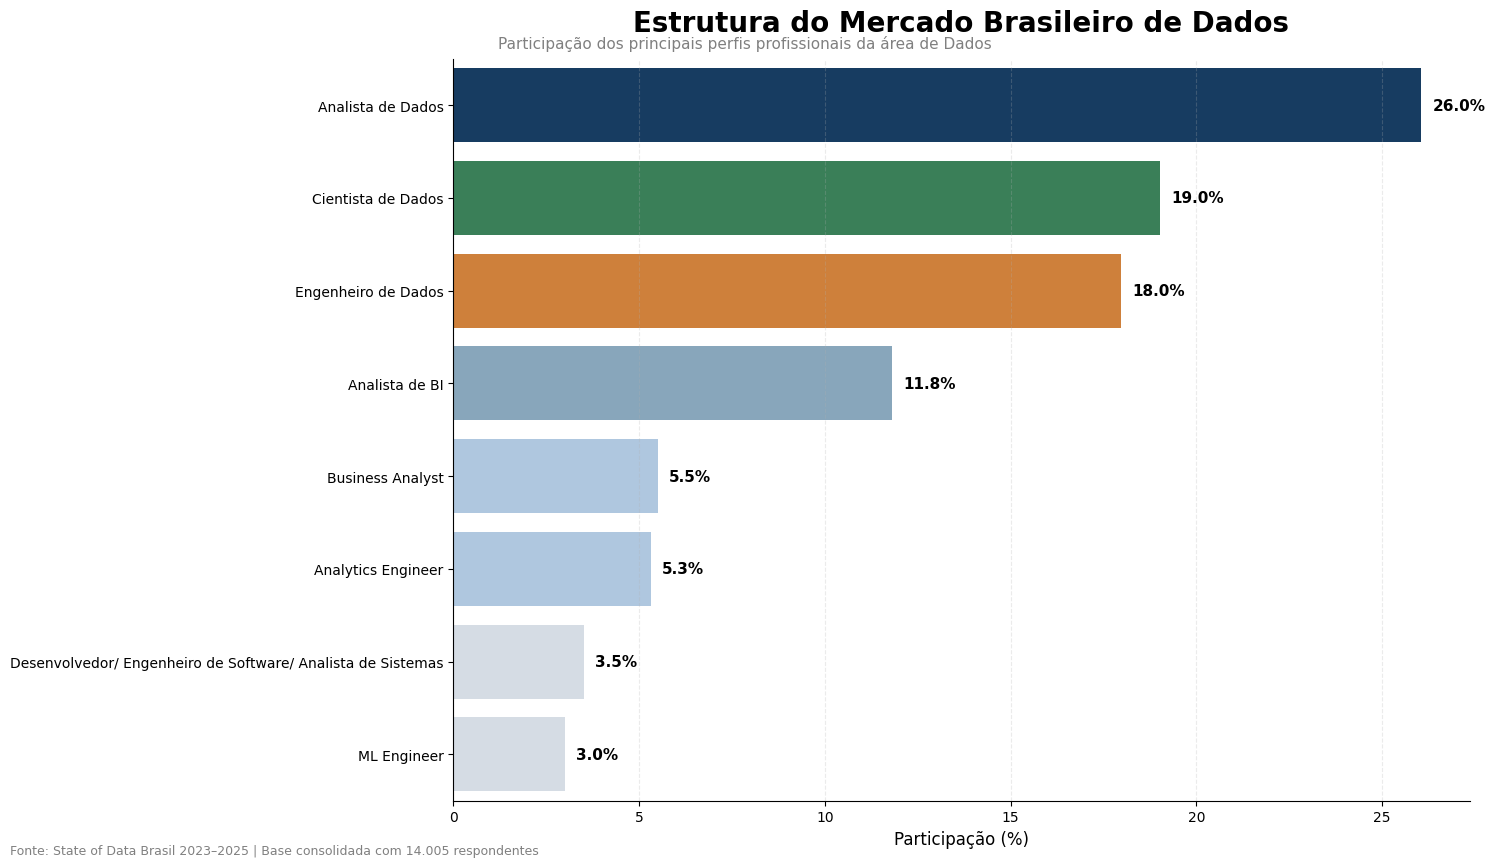

In [156]:
total_cargos_validos = gold_cargos_exec["count"].sum()

dados = gold_cargos_exec.head(8).copy()

dados["percentual"] = (
    dados["count"] / total_cargos_validos
) * 100

cores = [
    "#0B3C6D",  # Analista de Dados
    "#2E8B57",  # Cientista de Dados
    "#E67E22",  # Engenheiro de Dados
    "#7FA7C4",  # Analista BI
    "#A7C7E7",  # Business Analyst
    "#A7C7E7",  # Analytics Engineer
    "#D3DCE6",  # Desenvolvedor
    "#D3DCE6"   # ML Engineer
]

plt.figure(figsize=(15, 9))

ax = sns.barplot(
    data=dados,
    x="percentual",
    y="cargo_limpo",
    hue="cargo_limpo",
    palette=cores,
    legend=False
)

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.yaxis.grid(False)

sns.despine(
    left=False,
    bottom=False
)


plt.title(
    "Estrutura do Mercado Brasileiro de Dados",
    fontsize=20,
    fontweight="bold",
    pad=20
)


plt.suptitle(
    "Participação dos principais perfis profissionais da área de Dados",
    fontsize=11,
    y=0.92,
    color="gray"
)


plt.xlabel(
    "Participação (%)",
    fontsize=12
)

plt.ylabel(
    "",
    fontsize=12
)


for i, valor in enumerate(dados["percentual"]):
    ax.text(
        valor + 0.3,
        i,
        f"{valor:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )


plt.figtext(
    0.01,
    0.01,
    "Fonte: State of Data Brasil 2023–2025 | Base consolidada com 14.005 respondentes",
    fontsize=9,
    color="gray"
)


plt.tight_layout()

plt.show()

####Principais Achados

- Analistas de Dados representam aproximadamente 26% dos profissionais analisados.
- Cientistas de Dados representam aproximadamente 19%.
- Engenheiros de Dados representam aproximadamente 18%.
- Os três principais perfis concentram cerca de 63% da amostra.
- Analytics Engineer e ML Engineer demonstram o surgimento de especializações associadas à Inteligência Artificial e plataformas analíticas modernas.

**Conclusão**

  O mercado brasileiro de Dados permanece fortemente concentrado em funções analíticas e de engenharia. Ao mesmo tempo, observa-se o crescimento de perfis especializados ligados à Inteligência Artificial, Analytics Engineering e plataformas modernas de dados.

###**Diversidade de Gênero**

### Pergunta de Negócio

Qual é o cenário de diversidade de gênero entre os profissionais da área de Dados?

### Objetivo

Analisar a distribuição de gênero dos participantes da pesquisa State of Data Brasil.

### Metodologia

A análise utiliza o campo consolidado `genero` da camada Silver.

As categorias "Outro" e "Prefiro não informar" foram agrupadas em "Outros" para simplificar a visualização executiva.

In [157]:
gold_genero = (
    silver
    .where(F.col("genero").isNotNull())
    .groupBy("genero")
    .count()
    .orderBy(F.desc("count"))
)

gold_genero.show(truncate=False)

+--------------------+-----+
|genero              |count|
+--------------------+-----+
|Masculino           |10650|
|Feminino            |3287 |
|Prefiro não informar|44   |
|Outro               |24   |
+--------------------+-----+



#### *Principais Achados*

- O mercado continua predominantemente masculino.
- A participação feminina representa aproximadamente um quarto da amostra.
- A categoria "Outros" possui baixa representatividade na pesquisa.

### Conclusão

Apesar dos avanços observados nos últimos anos, ainda existe um desequilíbrio significativo de gênero no mercado brasileiro de Dados, indicando oportunidades para ampliação da diversidade e inclusão.

###**Distribuição Regional**

### Pergunta de Negócio

Como os profissionais de Dados estão distribuídos geograficamente pelo Brasil?

### Objetivo

Identificar as regiões com maior concentração de profissionais de Dados.

### Metodologia

A análise utiliza o campo consolidado `regiao` da camada Silver.

In [158]:
gold_regiao = (
    silver
    .where(F.col("regiao").isNotNull())
    .groupBy("regiao")
    .count()
    .orderBy(F.desc("count"))
)

gold_regiao_pd = gold_regiao.toPandas()

gold_regiao_pd

,regiao,count
0,Sudeste,8476
1,Sul,2532
2,Nordeste,1504
3,Centro-oeste,906
4,Norte,195
5,Distrito Federal (DF),1


/tmp/ipykernel_577/1926224887.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


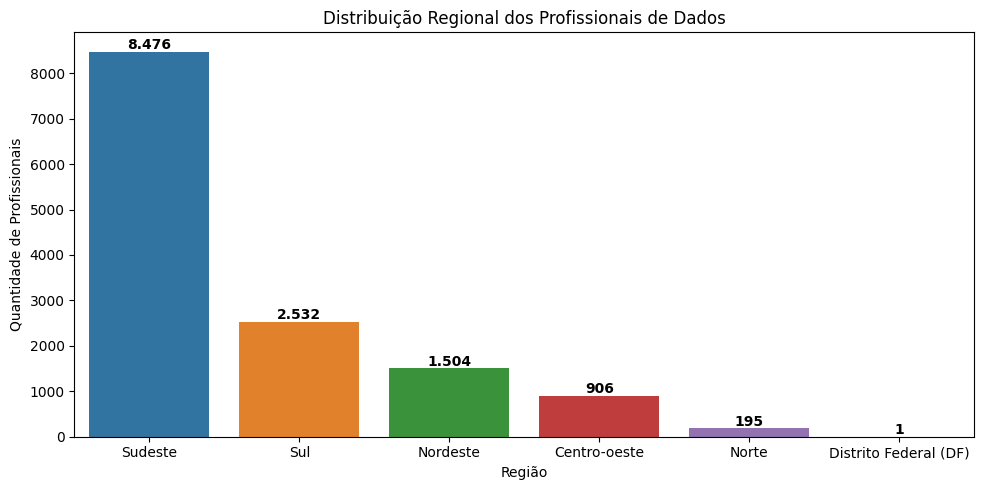

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

cores_regiao = {
    "Sudeste": "#1f77b4",       # Azul
    "Sul": "#ff7f0e",           # Laranja
    "Nordeste": "#2ca02c",      # Verde
    "Centro-oeste": "#d62728",  # Vermelho
    "Norte": "#9467bd",         # Roxo
    "Distrito Federal (DF)": "#8c564b"  # Marrom
}
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=gold_regiao_pd,
    x="regiao",
    y="count",
    palette=[cores_regiao[r] for r in gold_regiao_pd["regiao"]]
)

for i, v in enumerate(gold_regiao_pd["count"]):
    ax.text(
        i,
        v + 50,
        f"{v:,}".replace(",", "."),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Distribuição Regional dos Profissionais de Dados"
)

plt.xlabel("Região")
plt.ylabel("Quantidade de Profissionais")

plt.tight_layout()

plt.show()

#### *Principais Achados*

- A região Sudeste concentra a maior parcela dos profissionais.
- Sul e Nordeste aparecem como polos relevantes.
- Norte e Centro-Oeste apresentam menor representatividade na amostra.

### Conclusão

A distribuição regional evidencia a concentração da força de trabalho em Dados nos principais centros econômicos e tecnológicos do país.

###**Modelo de Trabalho**

### Pergunta de Negócio

Quais modelos de trabalho predominam entre os profissionais da área de Dados?

### Objetivo

Analisar o nível de adoção dos modelos remoto, híbrido e presencial.

### Metodologia

Os modelos de trabalho foram agrupados em:

- Remoto
- Híbrido Flexível
- Híbrido Fixo
- Presencial

In [160]:
gold_modelo = (
    silver
    .where(F.col("modelo_trabalho").isNotNull())
    .groupBy("modelo_trabalho")
    .count()
    .orderBy(F.desc("count"))
)

gold_modelo.show(
    truncate=False
)

+--------------------------------------------------------------------------------------------------------------+-----+
|modelo_trabalho                                                                                               |count|
+--------------------------------------------------------------------------------------------------------------+-----+
|Modelo 100% remoto                                                                                            |5705 |
|Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)|2602 |
|Modelo híbrido com dias fixos de trabalho presencial                                                          |2285 |
|Modelo 100% presencial                                                                                        |2251 |
|0                                                                                                             |1    |
+-----------------------------------------------

In [161]:
gold_modelo_pd = gold_modelo.toPandas()

gold_modelo_pd_exec = gold_modelo_pd.copy()

gold_modelo_pd_exec["modelo_limpo"] = (
    gold_modelo_pd_exec["modelo_trabalho"]
    .replace({

        "Modelo 100% remoto":
        "Remoto",

        "Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)":
        "Híbrido Flexível",

        "Modelo híbrido com dias fixos de trabalho presencial":
        "Híbrido Fixo",

        "Modelo 100% presencial":
        "Presencial"

    })
)

gold_modelo_pd_exec = gold_modelo_pd_exec[
    gold_modelo_pd_exec["modelo_limpo"] != "0"
]

In [162]:
gold_modelo_pd_exec["percentual"] = (
    gold_modelo_pd_exec["count"]
    / gold_modelo_pd_exec["count"].sum()
) * 100

gold_modelo_pd_exec

,modelo_trabalho,count,modelo_limpo,percentual
0,Modelo 100% remoto,5705,Remoto,44.421085
1,Modelo híbrido flexível (o funcionário tem lib...,2602,Híbrido Flexível,20.260064
2,Modelo híbrido com dias fixos de trabalho pres...,2285,Híbrido Fixo,17.791793
3,Modelo 100% presencial,2251,Presencial,17.527058


/tmp/ipykernel_577/2927187247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


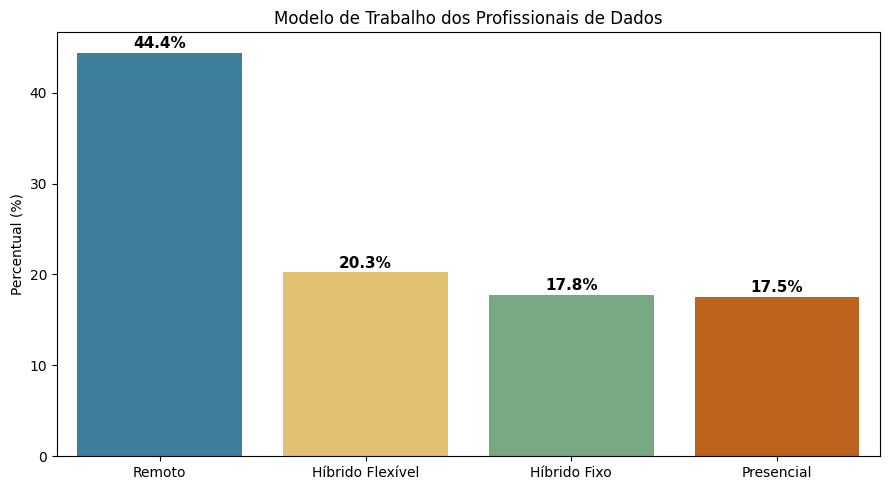

In [163]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=gold_modelo_pd_exec,
    x="modelo_limpo",
    y="percentual",
    palette=[
        "#2E86AB",
        "#F6C85F",
        "#6FB07F",
        "#D95F02"
    ]
)

for i, v in enumerate(
    gold_modelo_pd_exec["percentual"]
):
    ax.text(
        i,
        v + 0.5,
        f"{v:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Modelo de Trabalho dos Profissionais de Dados"
)

plt.xlabel("")
plt.ylabel("Percentual (%)")

plt.tight_layout()
plt.show()

#### *Principais Achados*

- O trabalho remoto representa o maior grupo.
- O modelo híbrido aparece como segunda alternativa mais utilizada.
- O modelo presencial possui menor participação relativa.

### Conclusão

A área de Dados apresenta forte aderência a modelos flexíveis de trabalho, com destaque para o remoto e o híbrido.

###**Adoção de Inteligência Artificial**

### Pergunta de Negócio

Como os profissionais da área de Dados utilizam Inteligência Artificial no dia a dia?

### Objetivo

Avaliar os diferentes modelos de utilização de IA generativa.

### Metodologia

As respostas foram agrupadas em:

- IA Gratuita
- IA Corporativa
- IA para Código
- IA Paga Individual
- Não utiliza IA

In [164]:
gold_ia = (
    silver
    .where(F.col("uso_ia").isNotNull())
    .groupBy("uso_ia")
    .count()
    .orderBy(F.desc("count"))
)

gold_ia.show(
    truncate=False
)


+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|uso_ia                                                                                                                                                                                                                                                                                                |count|
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|Utilizo apenas soluções gratuitas (como por exemplo o ChatGPT), para me ajudar a ser mais 

In [165]:
gold_ia_pd = gold_ia.toPandas()

def classificar_ia(texto):

    texto = str(texto).lower()

    if "não utilizo" in texto:
        return "Não utiliza IA"

    elif "copilot" in texto or "cursor" in texto:
        return "Copilot / IA para Código"

    elif "empresa em que trabalho paga" in texto:
        return "IA Corporativa"

    elif "pago do meu próprio bolso" in texto:
        return "IA Paga Individual"

    elif "gratuitas" in texto:
        return "IA Gratuita"

    return "Outros"

gold_ia_pd["categoria"] = (
    gold_ia_pd["uso_ia"]
    .apply(classificar_ia)
)

gold_ia_exec = (
    gold_ia_pd
    .groupby("categoria")["count"]
    .sum()
    .reset_index()
    .sort_values(
        by="count",
        ascending=False
    )
)

gold_ia_exec

,categoria,count
2,IA Gratuita,2089
0,Copilot / IA para Código,1485
1,IA Corporativa,1098
3,IA Paga Individual,773
4,Não utiliza IA,280


In [166]:
silver_ia = (
    silver

    .withColumn(
        "ia_nao_utiliza",
        F.when(
            F.lower(F.col("uso_ia")).contains("não utilizo"),
            1
        ).otherwise(0)
    )

    .withColumn(
        "ia_gratuita",
        F.when(
            F.lower(F.col("uso_ia")).contains("gratuit"),
            1
        ).otherwise(0)
    )

    .withColumn(
        "ia_paga_individual",
        F.when(
            F.lower(F.col("uso_ia")).contains("próprio bolso"),
            1
        ).otherwise(0)
    )

    .withColumn(
        "ia_corporativa",
        F.when(
            F.lower(F.col("uso_ia")).contains("empresa em que trabalho paga"),
            1
        ).otherwise(0)
    )

    .withColumn(
        "ia_codigo",
        F.when(
            F.lower(F.col("uso_ia")).contains("copilot")
            |
            F.lower(F.col("uso_ia")).contains("cursor")
            |
            F.lower(F.col("uso_ia")).contains("claude code"),
            1
        ).otherwise(0)
    )
)

In [167]:
silver_ia.agg(

    F.sum("ia_nao_utiliza").alias("nao_utiliza"),

    F.sum("ia_gratuita").alias("gratuita"),

    F.sum("ia_paga_individual").alias("paga_individual"),

    F.sum("ia_corporativa").alias("corporativa"),

    F.sum("ia_codigo").alias("ia_codigo")

).show()

+-----------+--------+---------------+-----------+---------+
|nao_utiliza|gratuita|paga_individual|corporativa|ia_codigo|
+-----------+--------+---------------+-----------+---------+
|        280|    2510|           1105|       1523|     1486|
+-----------+--------+---------------+-----------+---------+



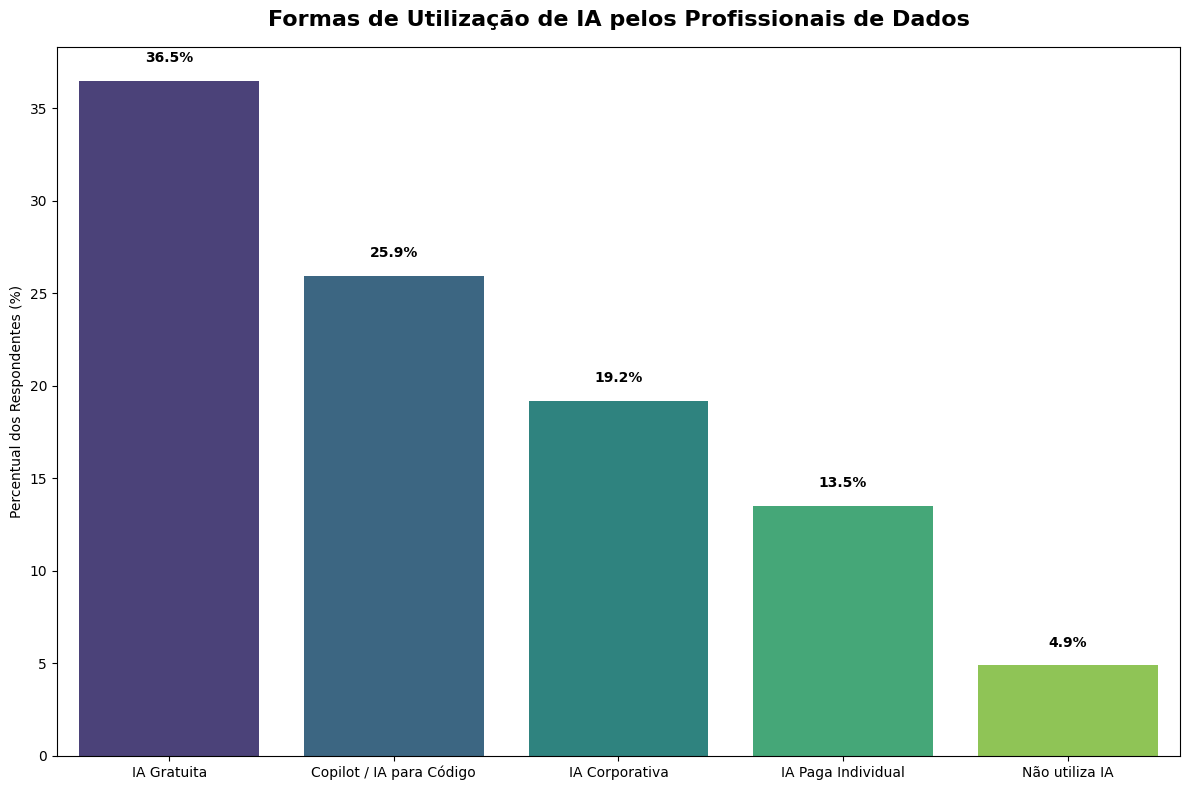

In [168]:
ia_exec = gold_ia_exec.copy()

total_ia = ia_exec["count"].sum()

ia_exec["Percentual"] = (
    ia_exec["count"] / total_ia
) * 100


plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=ia_exec,
    x="categoria",
    y="Percentual",
    hue="categoria",
    palette="viridis",
    legend=False
)

plt.title(
    "Formas de Utilização de IA pelos Profissionais de Dados",
    fontsize=16,
    fontweight="bold",
    pad=15
)


plt.ylabel("Percentual dos Respondentes (%)")
plt.xlabel("")


for i, valor in enumerate(ia_exec["Percentual"]):
    ax.text(
        i,
        valor + 1,
        f"{valor:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

#### *Principais Achados*

- IA Gratuita é a principal porta de entrada.
- IA Corporativa apresenta forte adoção.
- Assistentes de código já fazem parte da rotina de muitos profissionais.
- Poucos participantes declararam não utilizar IA.

### Conclusão

A Inteligência Artificial deixou de ser uma tecnologia experimental e já integra o trabalho cotidiano dos profissionais de Dados.

###**Uso de IA por Cargo**

### Pergunta de Negócio

Existe diferença na adoção de IA entre os diferentes perfis profissionais?

### Objetivo

Comparar a utilização de IA entre os principais cargos da área.

### Metodologia

Foram criados indicadores independentes para:

- IA Gratuita
- IA Corporativa
- IA para Código
- IA Paga Individual
- Não utiliza IA

As categorias não são mutuamente exclusivas.

In [169]:
silver_ia_cargo = (
    silver_ia

    .withColumn(
        "cargo_limpo",
        F.when(
            F.col("cargo") == "Analista de Dados/Data Analyst",
            "Analista de Dados"
        )
        .when(
            F.col("cargo") == "Cientista de Dados/Data Scientist",
            "Cientista de Dados"
        )
        .when(
            F.col("cargo").isin(
                "Engenheiro de Dados/Data Engineer/Data Architect",
                "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect"
            ),
            "Engenheiro de Dados"
        )
        .when(
            F.col("cargo") == "Analista de BI/BI Analyst",
            "Analista de BI"
        )
        .when(
            F.col("cargo") == "Analista de Negócios/Business Analyst",
            "Business Analyst"
        )
        .when(
            F.col("cargo") == "Engenheiro de Machine Learning/ML Engineer/AI Engineer",
            "ML Engineer"
        )
        .when(
            F.col("cargo") == "Analytics Engineer",
            "Analytics Engineer"
        )
        .otherwise(F.col("cargo"))
    )
)

In [170]:
cargos_principais = [
    "Analista de Dados",
    "Cientista de Dados",
    "Engenheiro de Dados",
    "Analista de BI",
    "Business Analyst",
    "Analytics Engineer",
    "ML Engineer"
]

base_ia_cargo = (
    silver_ia_cargo

    .where(
        F.col("cargo_limpo").isin(cargos_principais)
        &
        F.col("uso_ia").isNotNull()
    )
)

In [171]:
base_ia_cargo.groupBy("cargo_limpo") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(truncate=False)

+-------------------+-----+
|cargo_limpo        |count|
+-------------------+-----+
|Analista de Dados  |1503 |
|Cientista de Dados |1073 |
|Engenheiro de Dados|991  |
|Analista de BI     |584  |
|Analytics Engineer |353  |
|Business Analyst   |297  |
|ML Engineer        |190  |
+-------------------+-----+



In [172]:
gold_cargo_ia = (
    base_ia_cargo

    .groupBy("cargo_limpo")

    .agg(
        F.count("*").alias("respondentes_ia"),

        F.sum("ia_gratuita").alias("ia_gratuita"),

        F.sum("ia_corporativa").alias("ia_corporativa"),

        F.sum("ia_codigo").alias("ia_codigo"),

        F.sum("ia_paga_individual").alias("ia_paga_individual"),

        F.sum("ia_nao_utiliza").alias("nao_utiliza")
    )

    .withColumn(
        "pct_ia_gratuita",
        F.round(
            F.col("ia_gratuita") / F.col("respondentes_ia") * 100,
            1
        )
    )

    .withColumn(
        "pct_ia_corporativa",
        F.round(
            F.col("ia_corporativa") / F.col("respondentes_ia") * 100,
            1
        )
    )

    .withColumn(
        "pct_ia_codigo",
        F.round(
            F.col("ia_codigo") / F.col("respondentes_ia") * 100,
            1
        )
    )

    .withColumn(
        "pct_ia_paga_individual",
        F.round(
            F.col("ia_paga_individual") / F.col("respondentes_ia") * 100,
            1
        )
    )

    .withColumn(
        "pct_nao_utiliza",
        F.round(
            F.col("nao_utiliza") / F.col("respondentes_ia") * 100,
            1
        )
    )

    .orderBy(F.desc("respondentes_ia"))
)

In [173]:
gold_cargo_ia_pct = (
    gold_cargo_ia
    .select(
        "cargo_limpo",
        "respondentes_ia",

        F.round(
            F.col("ia_gratuita") /
            F.col("respondentes_ia") * 100,
            1
        ).alias("IA Gratuita"),

        F.round(
            F.col("ia_corporativa") /
            F.col("respondentes_ia") * 100,
            1
        ).alias("IA Corporativa"),

        F.round(
            F.col("ia_codigo") /
            F.col("respondentes_ia") * 100,
            1
        ).alias("IA para Código"),

        F.round(
            F.col("ia_paga_individual") /
            F.col("respondentes_ia") * 100,
            1
        ).alias("IA Paga Individual"),

        F.round(
            F.col("nao_utiliza") /
            F.col("respondentes_ia") * 100,
            1
        ).alias("Não utiliza IA")
    )
)

gold_cargo_ia_pct.show(truncate=False)

+-------------------+---------------+-----------+--------------+--------------+------------------+--------------+
|cargo_limpo        |respondentes_ia|IA Gratuita|IA Corporativa|IA para Código|IA Paga Individual|Não utiliza IA|
+-------------------+---------------+-----------+--------------+--------------+------------------+--------------+
|Analista de Dados  |1503           |47.9       |24.4          |19.6          |19.2              |5.7           |
|Cientista de Dados |1073           |38.5       |29.6          |35.1          |20.4              |2.9           |
|Engenheiro de Dados|991            |40.0       |27.7          |30.7          |18.7              |5.7           |
|Analista de BI     |584            |59.4       |16.4          |14.2          |18.7              |3.4           |
|Analytics Engineer |353            |37.4       |36.0          |29.2          |18.7              |3.7           |
|Business Analyst   |297            |45.8       |30.0          |19.2          |15.5     

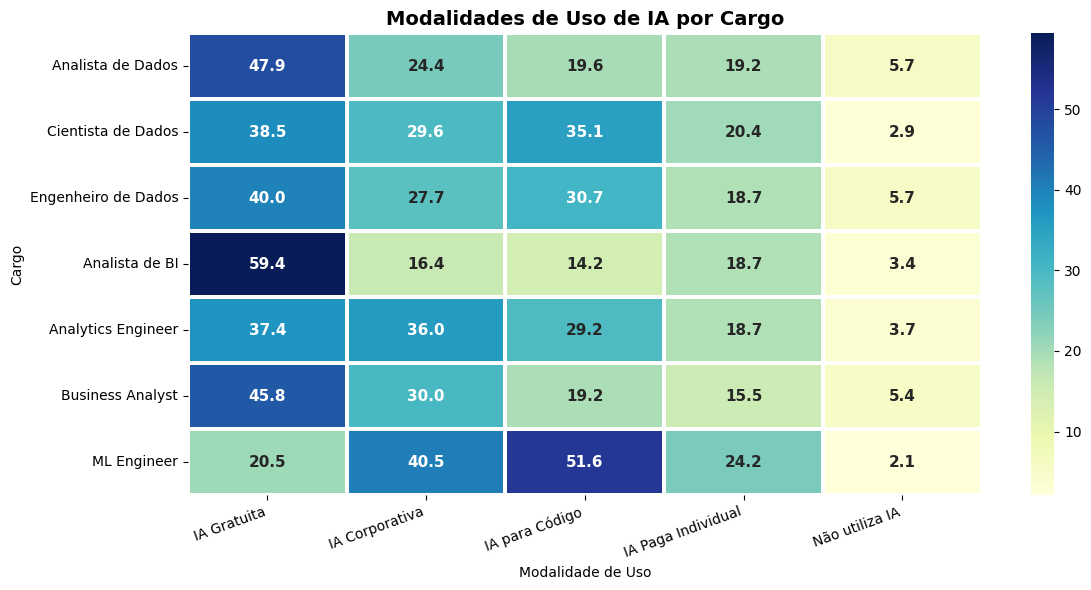

In [174]:
cargo_ia_pd = gold_cargo_ia_pct.toPandas()

ordem_cargos = [
    "Analista de Dados",
    "Cientista de Dados",
    "Engenheiro de Dados",
    "Analista de BI",
    "Analytics Engineer",
    "Business Analyst",
    "ML Engineer"
]

cargo_ia_pd["cargo_limpo"] = pd.Categorical(
    cargo_ia_pd["cargo_limpo"],
    categories=ordem_cargos,
    ordered=True
)

cargo_ia_pd = (
    cargo_ia_pd
    .sort_values("cargo_limpo")
    .set_index("cargo_limpo")
)

matriz_ia = cargo_ia_pd[
    [
        "IA Gratuita",
        "IA Corporativa",
        "IA para Código",
        "IA Paga Individual",
        "Não utiliza IA"
    ]
]

plt.figure(figsize=(12, 6))

sns.heatmap(
    matriz_ia,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=1.5,
    linecolor="white",
    annot_kws={
        "size":11,
        "weight":"bold"
    }
)

plt.title(
    "Modalidades de Uso de IA por Cargo",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Modalidade de Uso")
plt.ylabel("Cargo")

plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [175]:
base_cargos_ano = (
    silver_ia_cargo
    .where(
        F.col("cargo_limpo").isNotNull()
        &
        (F.trim(F.col("cargo_limpo")) != "")
        &
        (F.col("cargo_limpo") != "0")
        &
        (F.col("cargo_limpo") != "Outra Opção")
    )
)

base_cargos_ano.groupBy("ano_pesquisa") \
    .agg(
        F.count("*").alias("respondentes_com_cargo")
    ) \
    .orderBy("ano_pesquisa") \
    .show()

+------------+----------------------+
|ano_pesquisa|respondentes_com_cargo|
+------------+----------------------+
|        2023|                  3595|
|        2024|                  3564|
|        2025|                  2295|
+------------+----------------------+



In [176]:
from pyspark.sql import functions as F

base_cargos = (
    silver_ia_cargo
    .where(
        F.col("cargo_limpo").isNotNull()
        &
        (F.col("cargo_limpo") != "Outra Opção")
        &
        (F.col("cargo_limpo") != "0")
    )
)

total_ano = (
    base_cargos
    .groupBy("ano_pesquisa")
    .count()
    .withColumnRenamed(
        "count",
        "total_ano"
    )
)

cargo_ano = (
    base_cargos
    .groupBy(
        "ano_pesquisa",
        "cargo_limpo"
    )
    .count()
)

cargo_ano_pct = (
    cargo_ano
    .join(
        total_ano,
        "ano_pesquisa"
    )

    .withColumn(
        "percentual",
        F.round(
            F.col("count")
            /
            F.col("total_ano")
            * 100,
            2
        )
    )
)

cargo_ano_pct.show(
    truncate=False
)

+------------+-----------------------------------------------------------+-----+---------+----------+
|ano_pesquisa|cargo_limpo                                                |count|total_ano|percentual|
+------------+-----------------------------------------------------------+-----+---------+----------+
|2023        |Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)  |81   |3595     |2.25      |
|2023        |Cientista de Dados                                         |687  |3595     |19.11     |
|2023        |Professor/Pesquisador                                      |28   |3595     |0.78      |
|2023        |Economista                                                 |5    |3595     |0.14      |
|2023        |Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas|105  |3595     |2.92      |
|2023        |Engenheiro de Dados                                        |684  |3595     |19.03     |
|2023        |Analista de Inteligência de Mercado/Market Intelligence    |39   |35

In [177]:
cargo_ano_pd = cargo_ano_pct.toPandas()

principais = [
    "Analista de Dados",
    "Cientista de Dados",
    "Engenheiro de Dados",
    "Analytics Engineer",
    "ML Engineer"
]

cargo_ano_pd = cargo_ano_pd[
    cargo_ano_pd["cargo_limpo"].isin(principais)
]

In [178]:
matriz_cargos_ano = (
    cargo_ano_pd
    .pivot(
        index="cargo_limpo",
        columns="ano_pesquisa",
        values="percentual"
    )
    .reindex(ordem_cargos)
    .fillna(0)
)

ordem_cargos = [
    "Analista de Dados",
    "Cientista de Dados",
    "Engenheiro de Dados",
    "Analytics Engineer",
    "ML Engineer"
]

matriz_cargos_ano = matriz_cargos_ano.reindex(ordem_cargos)

matriz_cargos_ano

ano_pesquisa,2023,2024,2025
cargo_limpo,,,
Analista de Dados,25.23,26.85,26.10
Cientista de Dados,19.11,19.28,18.47
Engenheiro de Dados,19.03,17.20,17.52
Analytics Engineer,3.87,6.40,5.88
ML Engineer,2.09,2.89,4.62


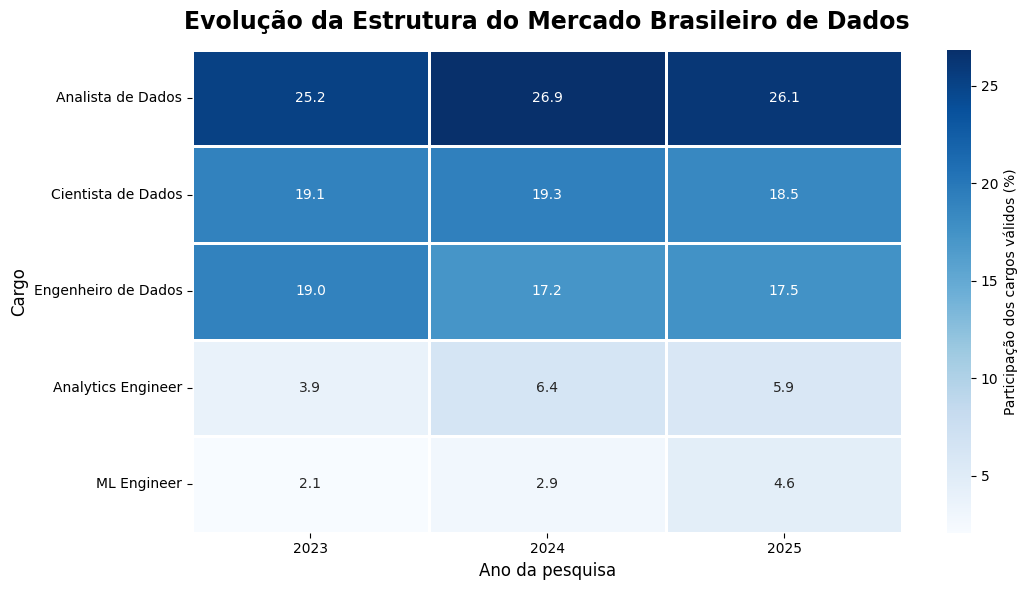

In [179]:
plt.figure(figsize=(11, 6))

ax = sns.heatmap(
    matriz_cargos_ano,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=1,
    linecolor="white",
    cbar_kws={
        "label": "Participação dos cargos válidos (%)"
    }
)

plt.title(
    "Evolução da Estrutura do Mercado Brasileiro de Dados",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Ano da pesquisa",
    fontsize=12
)

plt.ylabel(
    "Cargo",
    fontsize=12
)

plt.tight_layout()

plt.show()

#### *Principais Achados*

- ML Engineers lideram IA Corporativa.
- ML Engineers lideram IA para Código.
- Analistas de BI apresentam maior utilização de IA Gratuita.
- A taxa de não utilização é baixa em todos os cargos.

### Conclusão

A maturidade de adoção de IA varia por perfil profissional, sendo mais intensa entre funções associadas à Engenharia e Inteligência Artificial.

###**Evolução dos Principais Cargos**

### Pergunta de Negócio

Como a participação dos cargos evoluiu entre 2023 e 2025?

### Objetivo

Identificar tendências e mudanças na composição do mercado brasileiro de Dados.

### Metodologia

As análises utilizam participação percentual por ano para evitar distorções causadas por diferenças no tamanho das amostras.

In [180]:
cargo_ano_pd = cargo_ano_pct.toPandas()

principais = [
    "Analista de Dados",
    "Cientista de Dados",
    "Engenheiro de Dados",
    "Analytics Engineer",
    "ML Engineer"
]

cargo_ano_pd = cargo_ano_pd[
    cargo_ano_pd["cargo_limpo"].isin(principais)
]

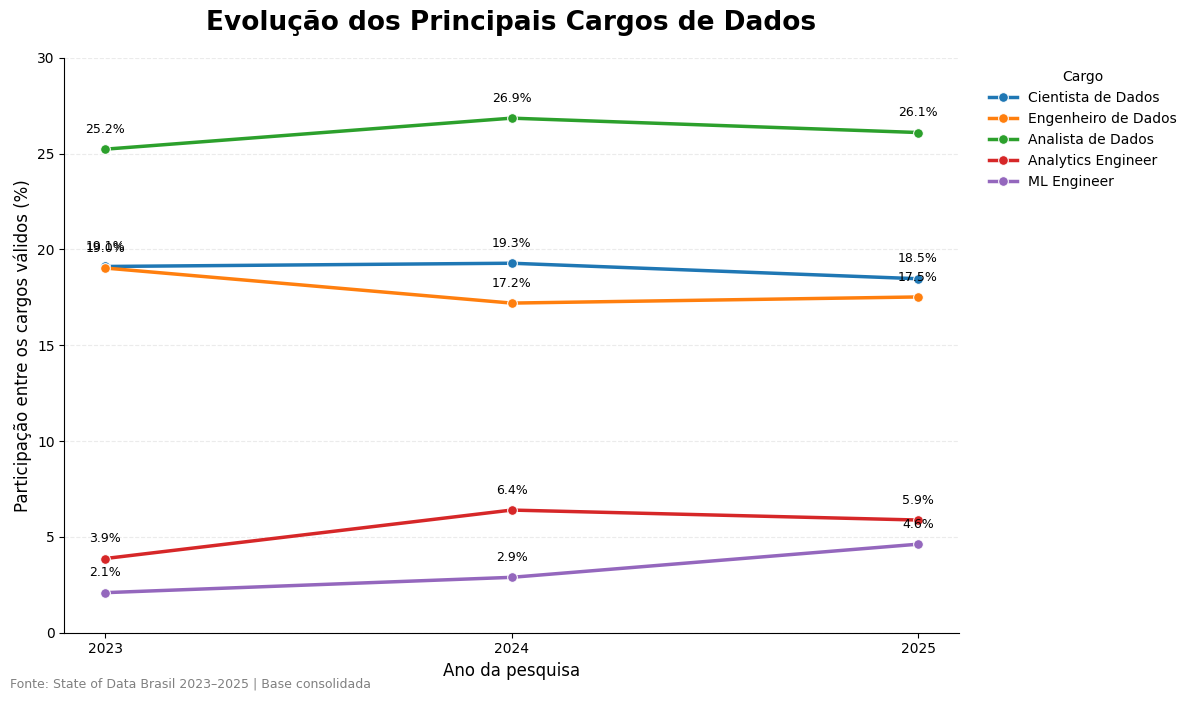

In [181]:
# ==========================================
# Evolução dos Principais Cargos de Dados
# ==========================================

plt.figure(figsize=(12, 7))

# Gráfico de linhas
ax = sns.lineplot(
    data=cargo_ano_pd,
    x="ano_pesquisa",
    y="percentual",
    hue="cargo_limpo",
    marker="o",
    linewidth=2.5,
    markersize=7
)

# Título
plt.title(
    "Evolução dos Principais Cargos de Dados",
    fontsize=19,
    fontweight="bold",
    pad=20
)



# Eixos
plt.xlabel(
    "Ano da pesquisa",
    fontsize=12
)

plt.ylabel(
    "Participação entre os cargos válidos (%)",
    fontsize=12
)

# Limites do eixo Y
plt.ylim(0, 30)

# Grade
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

# Remove bordas superiores e direita
sns.despine()

# Legenda
plt.legend(
    title="Cargo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# Adiciona os valores em cada ponto
for _, grupo in cargo_ano_pd.groupby("cargo_limpo"):

    for _, linha in grupo.iterrows():

        ax.text(
            linha["ano_pesquisa"],
            linha["percentual"] + 0.7,
            f'{linha["percentual"]:.1f}%',
            ha="center",
            va="bottom",
            fontsize=9
        )

# Fonte
plt.figtext(
    0.01,
    0.01,
    "Fonte: State of Data Brasil 2023–2025 | Base consolidada",
    fontsize=9,
    color="gray"
)

plt.tight_layout()

plt.show()

#### *Principais Achados*

- Analista de Dados permanece o principal cargo.
- Ciência de Dados mantém participação relevante.
- Analytics Engineer ganha espaço.
- ML Engineer apresenta crescimento consistente.

### Conclusão

O mercado de Dados continua concentrado em funções analíticas tradicionais, mas demonstra crescimento gradual de especializações ligadas à Engenharia, Analytics e Inteligência Artificial.

A

### **Remuneração e Cargo**

### Pergunta de Negócio

Quais cargos apresentam maior concentração nas faixas de remuneração mais elevadas?

### Objetivo

Avaliar a relação entre os principais cargos do mercado de Dados e as faixas de remuneração, identificando quais funções apresentam maior concentração de profissionais com salários superiores a **R$ 12.000/mês**.

### Metodologia

A análise considera os registros que possuem informação de faixa salarial disponível e os principais cargos padronizados nas diferentes edições da pesquisa.

Para facilitar a comparação entre os cargos, foi utilizado como indicador de remuneração elevada o percentual de profissionais inseridos nas faixas salariais **acima de R$ 12.000/mês**.

> **Observação:** a análise é descritiva da amostra disponível para a variável salarial. A edição de 2023 não apresentou registros válidos para essa variável no conjunto utilizado.

In [220]:
df_salario.groupBy("ano_pesquisa").count().orderBy("ano_pesquisa").show()

+------------+-----+
|ano_pesquisa|count|
+------------+-----+
|        2024| 4863|
|        2025| 3227|
+------------+-----+



In [222]:
df_salario_cargo = df_salario_cargo.withColumn(
    "cargo_limpo",
    F.when(
        F.col("cargo_atual") == "Analista de Dados/Data Analyst",
        "Analista de Dados"
    ).when(
        F.col("cargo_atual") == "Cientista de Dados/Data Scientist",
        "Cientista de Dados"
    ).when(
        F.col("cargo_atual") == "Analista de BI/BI Analyst",
        "Analista de BI"
    ).when(
        F.col("cargo_atual") == "Analista de Negócios/Business Analyst",
        "Business Analyst"
    ).when(
        F.col("cargo_atual") == "Analytics Engineer",
        "Analytics Engineer"
    ).when(
        F.col("cargo_atual") == "Engenheiro de Machine Learning/ML Engineer/AI Engineer",
        "ML Engineer"
    ).when(
        F.col("cargo_atual") == "Engenheiro de Dados/Data Engineer/Data Architect",
        "Engenheiro de Dados"
    ).when(
        F.col("cargo_atual") == "Arquiteto de Dados/Data Architect",
        "Arquiteto de Dados"
    ).otherwise(F.col("cargo_atual"))
)

In [211]:
cargos_salario = [
    "Analista de Dados",
    "Cientista de Dados",
    "Engenheiro de Dados",
    "Analista de BI",
    "Analytics Engineer",
    "ML Engineer",
    "Arquiteto de Dados"
]

df_salario_principais = df_salario_cargo.filter(
    F.col("cargo_limpo").isin(cargos_salario)
)

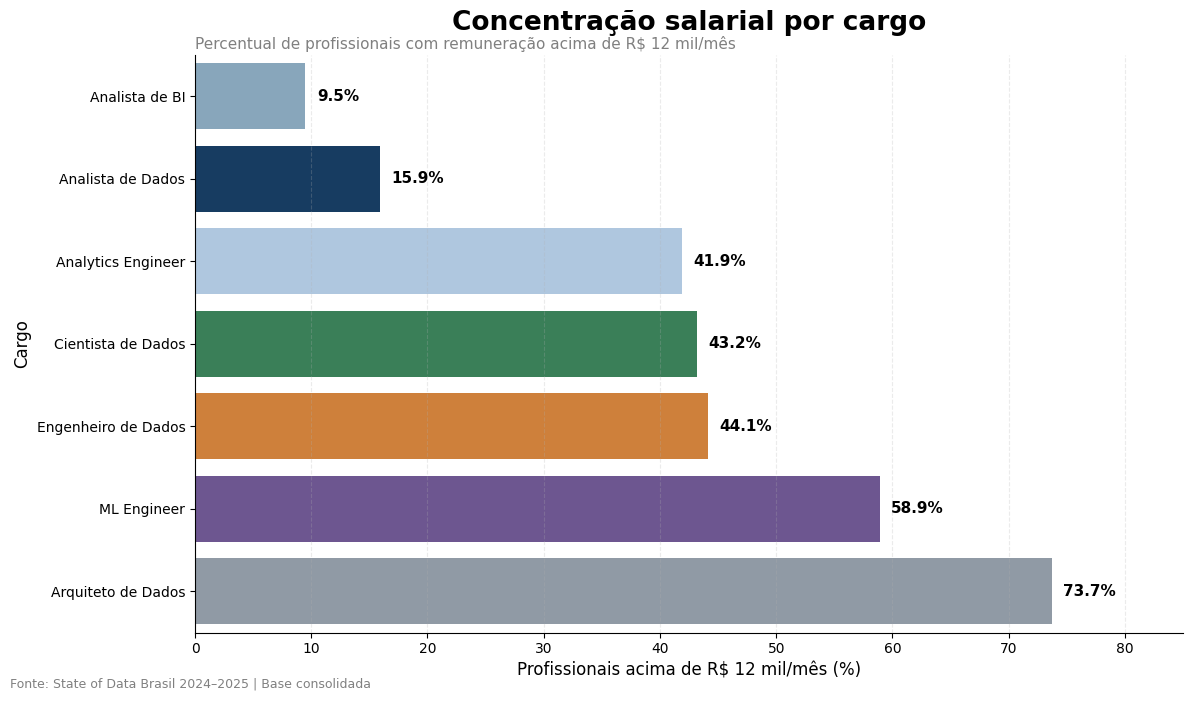

In [227]:
grafico_salario = gold_salario_alto.toPandas()

ordem_cargos = [
    "Analista de BI",
    "Analista de Dados",
    "Analytics Engineer",
    "Cientista de Dados",
    "Engenheiro de Dados",
    "ML Engineer",
    "Arquiteto de Dados"
]

cores_cargos = {
    "Analista de Dados": "#0B3C6D",
    "Cientista de Dados": "#2E8B57",
    "Engenheiro de Dados": "#E67E22",
    "Analista de BI": "#7FA7C4",
    "Analytics Engineer": "#A7C7E7",
    "Arquiteto de Dados": "#8C9AA8",
    "ML Engineer": "#6B4C9A"
}

grafico_salario["cargo_limpo"] = pd.Categorical(
    grafico_salario["cargo_limpo"],
    categories=ordem_cargos,
    ordered=True
)

grafico_salario = grafico_salario.sort_values("cargo_limpo")

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=grafico_salario,
    x="percentual_acima_12k",
    y="cargo_limpo",
    hue="cargo_limpo",
    palette=cores_cargos,
    legend=False
)

plt.title(
    "Concentração salarial por cargo",
    fontsize=19,
    fontweight="bold",
    pad=18
)

plt.text(
    0,
    1.01,
    "Percentual de profissionais com remuneração acima de R$ 12 mil/mês",
    transform=ax.transAxes,
    fontsize=11,
    color="gray"
)

plt.xlabel(
    "Profissionais acima de R$ 12 mil/mês (%)",
    fontsize=12
)

plt.ylabel(
    "Cargo",
    fontsize=12
)

plt.xlim(0, 85)

for i, valor in enumerate(grafico_salario["percentual_acima_12k"]):
    ax.text(
        valor + 1,
        i,
        f"{valor:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

sns.despine()

plt.figtext(
    0.01,
    0.01,
    "Fonte: State of Data Brasil 2024–2025 | Base consolidada",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

#### *Principais Achados*

- **Arquiteto de Dados** apresenta a maior concentração de profissionais acima de R$ 12 mil/mês, com **73,7%**.
- **ML Engineer** aparece em seguida, com **58,9%**.
- **Engenheiro de Dados** apresenta **44,1%** dos profissionais acima dessa faixa.
- **Cientista de Dados** apresenta resultado semelhante, com **43,2%**.
- **Analytics Engineer** apresenta **41,9%**.
- **Analista de Dados** apresenta uma concentração menor, com **15,9%**.
- **Analista de BI** apresenta **9,5%**, sendo o menor percentual entre os cargos analisados.

### Conclusão

Os resultados indicam uma forte concentração das faixas salariais mais elevadas em cargos de maior especialização técnica.

Funções relacionadas à **Arquitetura de Dados, Machine Learning e Engenharia de Dados** apresentam maior proporção de profissionais com remuneração acima de R$ 12 mil/mês.

Para uma instituição financeira, esse cenário reforça a importância de estratégias específicas de **contratação, desenvolvimento e retenção** de profissionais com competências críticas em Engenharia de Dados, Machine Learning e Arquitetura de Dados.

# Arquitetura e Pipeline de Dados na AWS

A solução proposta utiliza uma arquitetura de processamento em camadas,
seguindo o conceito de Data Lake.

Os dados do State of Data Brasil 2023, 2024 e 2025 são inicialmente
armazenados no Amazon S3 na camada Bronze, preservando os dados em seu
formato original.

O AWS Glue é utilizado para catalogação e processamento dos dados,
utilizando Apache Spark/PySpark para as etapas de transformação e
padronização.

Na camada Silver são mantidas as informações relevantes para a análise,
após tratamento, padronização e harmonização das variáveis entre os
diferentes anos da pesquisa.

A camada Gold contém as tabelas analíticas utilizadas para responder às
questões de negócio, como estrutura do mercado, diversidade, região,
modelo de trabalho, adoção de IA, evolução dos cargos e remuneração.

O Amazon Athena permite realizar consultas SQL sobre os dados catalogados,
enquanto as ferramentas de visualização podem consumir as tabelas Gold
para construção dos dashboards e análises executivas.

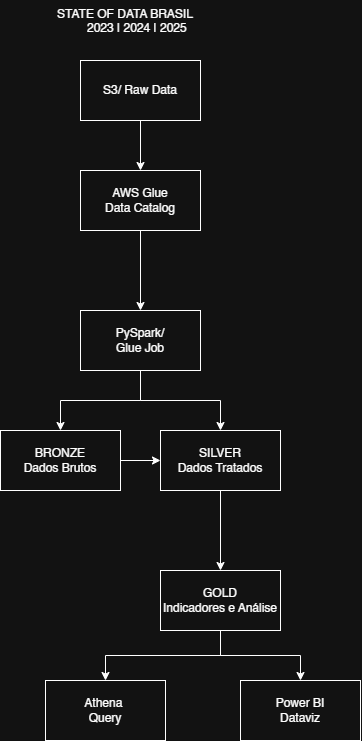

# Insights e Recomendações para Instituições Financeiras

## 1. O mercado de dados está se especializando

### Insight

A evolução dos principais cargos entre 2023 e 2025 evidencia mudanças na composição do mercado brasileiro de profissionais de dados, com presença relevante de funções especializadas em engenharia, analytics e machine learning.

### Implicação para a instituição financeira

A evolução dos perfis profissionais indica a necessidade de acompanhar continuamente as competências disponíveis no mercado e estruturar estratégias específicas para:

- Contratação de profissionais especializados;
- Formação e desenvolvimento interno;
- Planejamento de carreira;
- Retenção de talentos críticos.

---

## 2. A Inteligência Artificial já faz parte da rotina dos profissionais de dados

### Insight

A análise de adoção de IA demonstra que diferentes formas de ferramentas de Inteligência Artificial já estão presentes na rotina dos profissionais avaliados.

### Implicação para a instituição financeira

A adoção de IA representa uma oportunidade para aumentar produtividade e capacidade analítica, mas exige uma estratégia estruturada envolvendo:

- Capacitação dos profissionais;
- Definição de ferramentas autorizadas;
- Governança do uso de IA;
- Segurança da informação;
- Uso responsável dos dados.

---

## 3. O uso de IA varia de acordo com o perfil profissional

### Insight

A análise de **Uso de IA por Cargo** mostra que a adoção das ferramentas não ocorre de maneira uniforme entre as diferentes funções da área de dados.

### Implicação para a instituição financeira

A estratégia de adoção de IA deve considerar as características de cada função, direcionando:

- Treinamentos específicos;
- Ferramentas adequadas para cada perfil;
- Casos de uso prioritários;
- Políticas de utilização;
- Desenvolvimento de competências relacionadas à IA.

---

## 4. Cargos especializados apresentam maior concentração salarial

### Insight

A análise de remuneração mostra uma diferença significativa na concentração de profissionais que recebem acima de **R$ 12 mil/mês**.

| Cargo | Acima de R$ 12 mil/mês |
|---|---:|
| Arquiteto de Dados | **73,7%** |
| ML Engineer | **58,9%** |
| Engenheiro de Dados | **44,1%** |
| Cientista de Dados | **43,2%** |
| Analytics Engineer | **41,9%** |
| Analista de Dados | **15,9%** |
| Analista de BI | **9,5%** |

### Implicação para a instituição financeira

Os dados sinalizam maior pressão de custo e potencial desafio de retenção nos perfis mais especializados.

A instituição pode, portanto, priorizar:

- Políticas de retenção para competências críticas;
- Remuneração competitiva;
- Planos de carreira especializados;
- Desenvolvimento técnico contínuo;
- Identificação de posições estratégicas com maior risco de perda de talentos.

> **Observação:** os dados demonstram associação entre perfil profissional e concentração salarial, mas não permitem afirmar que o cargo, isoladamente, determina a remuneração.

---

## 5. O modelo de trabalho influencia a estratégia de contratação

### Insight

A distribuição dos profissionais entre diferentes modelos de trabalho permite avaliar o potencial de contratação além dos centros geográficos tradicionais.

### Implicação para a instituição financeira

Modelos híbridos e remotos podem ampliar o universo de profissionais disponíveis para funções especializadas, permitindo:

- Recrutamento em diferentes regiões;
- Acesso a mercados de talentos mais amplos;
- Maior flexibilidade na composição das equipes;
- Redução da dependência de determinados polos geográficos.

---

# Recomendações Estratégicas

## 1. Priorizar a retenção de competências críticas

Concentrar esforços de retenção em profissionais de **Engenharia de Dados, Machine Learning e Arquitetura de Dados**, considerando sua maior especialização e concentração nas faixas salariais superiores.

## 2. Estruturar uma estratégia de capacitação em IA

Desenvolver programas de capacitação diferenciados por perfil profissional, combinando produtividade, governança, segurança e uso responsável de Inteligência Artificial.

## 3. Ampliar o alcance da estratégia de recrutamento

Utilizar modelos de trabalho remoto e híbrido como instrumento para ampliar o acesso a profissionais especializados, reduzindo limitações geográficas no recrutamento.

---

# Síntese Executiva

> **O mercado brasileiro de dados está se tornando mais especializado, enquanto a Inteligência Artificial ganha espaço na rotina profissional. Para uma instituição financeira, esse cenário exige uma estratégia de talentos baseada em três pilares: reter competências críticas, acelerar a capacitação em IA e ampliar o acesso a profissionais especializados.**

### Mensagem central

**Dados → Especialização → IA → Talentos críticos → Estratégia de negócio**